In [7]:
import numpy as np                           
import pandas as pd                                 
import matplotlib.pyplot as plt 

from sklearn.pipeline import Pipeline           
from sklearn.compose import ColumnTransformer     
from sklearn.preprocessing import StandardScaler, RobustScaler      
from sklearn.preprocessing import OneHotEncoder       
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR 
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [2]:
data = pd.read_csv("..\\data\\train_post_modif_median.csv")
data.head()

,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Power,Price,Model,Brand
0,2010,72000,CNG,Manual,First,26.60,58.16,1627.325,WAGON R LXI CNG,MARUTI
1,2015,41000,Diesel,Manual,First,19.67,126.20,11623.750,CRETA 1.6 CRDI SX OPTION,HYUNDAI
2,2011,46000,Petrol,Manual,First,18.20,88.70,4184.550,JAZZ V,HONDA
3,2012,87000,Diesel,Manual,First,20.77,88.76,5579.400,ERTIGA VDI,MARUTI
4,2013,40670,Diesel,Automatic,Second,15.20,140.80,16496.426,A4 NEW 2.0 TDI MULTITRONIC,AUDI


In [4]:
X = data.drop(columns=["Price"])
y = data["Price"] 

In [5]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[                       
    ("scaler", RobustScaler())                       
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),     
        ("cat", categorical_transformer, categorical_features)  
    ]
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                                           
    test_size=0.2,                              
    random_state=42                                
)

In [ ]:
svr_model1 = Pipeline(steps=[
    ("preprocess", preprocess),                     
    ("model", SVR(kernel="poly", C=10, gamma="scale", epsilon=0.1)) 
])

svr_model1.fit(X_train, y_train)                       
print("SVR trained (fixed hyperparameters).") 

SVR trained (fixed hyperparameters).


In [9]:
def evaluate_regression(model, X_test, y_test, name="model"):
    """
    Evaluate a regression model on the test set using:
    - MAE
    - RMSE
    - R²
    Also plots Actual vs Predicted.
    """
    preds = model.predict(X_test)                     

    mae = mean_absolute_error(y_test, preds)          
    rmse = np.sqrt(mean_squared_error(y_test, preds)) 
    r2 = r2_score(y_test, preds)                      

    print(f"\n--- {name} ---")                        
    print(f"MAE : {mae:.4f}")                         
    print(f"RMSE: {rmse:.4f}")                        
    print(f"R^2 : {r2:.4f}")                          

    plt.figure()                                      
    plt.scatter(y_test, preds, s=8)                   
    plt.title(f"{name}: Actual vs Predicted")         
    plt.xlabel("Actual")                              
    plt.ylabel("Predicted")                           
    plt.show()                                        

    return mae, rmse, r2 


--- SVR (fixed params) ---
MAE : 4369.5730
RMSE: 9549.3526
R^2 : 0.1430


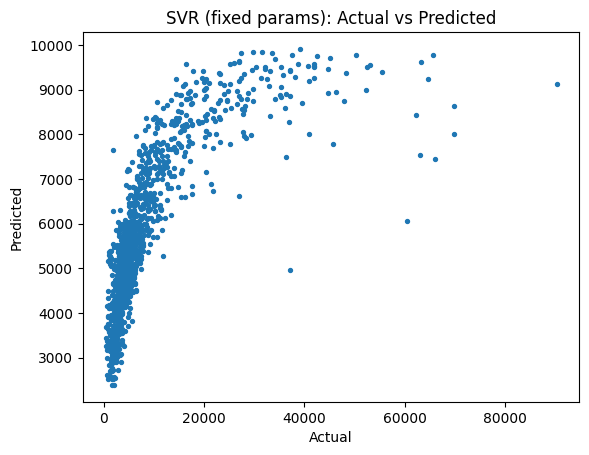

In [10]:
svr_scores = evaluate_regression(                      
    svr_model1,                                        
    X_test,                                           
    y_test,                                            
    "SVR (fixed params)"                               
)